In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from tqdm.auto import tqdm
from scipy.special import logit,expit
plt.style.use('ggplot')

from correlation_correction.methods import gl_methods as gl
from correlation_correction.methods import hamling_methods as ham
from correlation_correction.regressions import gls_reg, wls_reg, _create_covariance_matrix

In [39]:
# Setting seed
golden_seed = 6
seed = 8
np.random.seed(seed)

# Initializing simulation slope and intercept parameters
beta0 = -0.1
beta1 = 0.02
beta_age = 0.05
beta_income = -0.05
beta_sex = 1.0

# Number of samples
n = 40000

# Constructing covariate vectors for additional covariates to adjust
age_vector = np.random.uniform(low=0,high=1,size=n)
income_vector = np.random.uniform(low=0,high=1,size=n)
# sex_vector = np.random.binomial(n=1,p=0.6,size=n)

# Assigning exposure levels and getting relevant x's
exposure_levels = np.array([0.,1.,2.,3.])
xs = np.random.choice(exposure_levels,size = n)
sex_vector = np.random.binomial(n = 1,p = 0.1 + xs/4,size =n )


# Function to generate probabilities of being a case v non-case
other_covs = beta0 + (beta_age*age_vector) + (income_vector*beta_income) + (sex_vector*beta_sex) 
p = lambda x: (np.exp(beta1*x + other_covs))/(1 + np.exp(beta1*x + other_covs))

# Actually calculating probabilities on exposures as defined
px = p(xs)

# Actually assigning to case or not
outcomes = np.array([np.random.binomial(n=1,p=p,size=1)[0] for p in px])

# Constructing and sorting dataframe of outcomes and exposure
df = np.stack([outcomes,xs],axis=1)
# df = df[np.argsort(df[:, 1])]

# Getting xs corresponding to each exposure interval and corresponding case information
categories = [df[np.where(df[:,1] == i)[0]] for i in exposure_levels]
N = np.array([df.shape[0] for df in categories])
cases = np.array([np.sum(df[:,0]) for df in categories])
non_cases = N - cases
a_0, A = cases[0], cases[1:]
b_0, B = non_cases[0], non_cases[1:]
M = np.sum(cases)
p = b_0 / np.sum(non_cases)
z = np.sum(non_cases) / np.sum(cases)

# Getting crude estimates to compare
crude = lambda x,y: (x/y) / (a_0/b_0)
crudeors = crude(A,B)

# Constructing dummy variables with respect to exposure level
x = exposure_levels[1:]

to_adjust_df = pd.DataFrame({
    'age':age_vector,
    'income':income_vector,
    'sex':sex_vector,
    'exposure':xs.astype(int)
})
to_adjust_df['intercept']=1

to_adjust_df = pd.concat([to_adjust_df,pd.get_dummies(to_adjust_df['exposure'],prefix='exposure').astype(int).iloc[:,1:]],axis=1).drop('exposure',axis=1)

results = sm.Logit(endog=df[:,0], exog=to_adjust_df).fit()
true_C = results.cov_params().to_numpy()[4:,4:]
true_C_inv = np.linalg.inv(true_C)

# Get log-ORs and corresponding variances
L = results.params.to_numpy()[4:]
v = (results.bse.to_numpy()[4:])**2

Optimization terminated successfully.
         Current function value: 0.645992
         Iterations 5


In [40]:
counts_ham = ham.hamling(L,p,z,v)
counts_gl = gl.convex_gl(L,N,M)

In [41]:
b_true, v_true = gls_reg(true_C_inv,L,x)
b_gl, v_gl = gls_reg(np.linalg.inv(counts_gl.cov(v)),L,x)
b_ham, v_ham = gls_reg(np.linalg.inv(counts_ham.cov(v)),L,x)

In [42]:
print(f"This is the true slope: {b_true} and variance: {v_true}")
print(f"This is the GL slope: {b_gl} and variance: {v_gl}")
print(f"This is the Hamling slope: {b_ham} and variance: {v_ham}")

This is the true slope: 0.012455857235796616 and variance: 34.61055266546174
This is the GL slope: 0.012414881379856265 and variance: 35.751662206580555
This is the Hamling slope: 0.012485630362538611 and variance: 38.773273056624426


#### Simulation

In [62]:
GL_pe_list = []
GL_v_list = []
oracle_pe_list = []
oracle_v_list = []
OLS_pe_list = []
OLS_v_list = []
crude_pe_list = []
crude_v_list = []
hamling_pe_list = []
hamling_v_list = []

crude_cov = []
gl_cov = []
ham_cov = []
oracle_cov = []

# Setting seed
# golden_seed = 6
# seed = 8
# np.random.seed(seed)

# Initializing simulation slope and intercept parameters
beta0 = -0.1
beta1 = 0.02
beta_age = 1.
beta_income = -0.05
beta_sex = 5.0

# Number of samples
n = 10000

# Simulation number
sim_no = 500

# Running the simulation
for i in tqdm(range(sim_no)):
    # Constructing covariate vectors for additional covariates to adjust
    age_vector = np.random.uniform(low=0,high=1,size=n)
    income_vector = np.random.uniform(low=0,high=1,size=n)
    # sex_vector = np.random.binomial(n=1,p=0.6,size=n)

    # Assigning exposure levels and getting relevant x's
    exposure_levels = np.array([0.,1.,2.,3.])
    xs = np.random.choice(exposure_levels,size = n,p = np.array([0.04,0.32,0.32,0.32]))
    sex_vector = np.random.binomial(n = 1,p = 0.1 + xs/4,size =n )


    # Function to generate probabilities of being a case v non-case
    other_covs = beta0 + (beta_age*age_vector) + (income_vector*beta_income) + (sex_vector*beta_sex) 
    #p = lambda x: (np.exp(beta1*x + other_covs))/(1 + np.exp(beta1*x + other_covs))
    px = (expit(beta1*xs+other_covs))

    # Actually calculating probabilities on exposures as defined
    #px = p(xs)

    # Actually assigning to case or not
    outcomes = np.array([np.random.binomial(n=1,p=p,size=1)[0] for p in px])

    # Constructing and sorting dataframe of outcomes and exposure
    df = np.stack([outcomes,xs],axis=1)
    # df = df[np.argsort(df[:, 1])]

    # Getting xs corresponding to each exposure interval and corresponding case information
    categories = [df[np.where(df[:,1] == i)[0]] for i in exposure_levels]
    N = np.array([df.shape[0] for df in categories])
    cases = np.array([np.sum(df[:,0]) for df in categories])
    non_cases = N - cases
    a_0, A = cases[0], cases[1:]
    b_0, B = non_cases[0], non_cases[1:]
    M = np.sum(cases)
    p = b_0 / np.sum(non_cases)
    z = np.sum(non_cases) / np.sum(cases)

    # Getting crude estimates to compare
    crude = lambda x,y: (x/y) / (a_0/b_0)
    crudeors = crude(A,B)

    # Constructing dummy variables with respect to exposure level
    x = exposure_levels[1:]

    to_adjust_df = pd.DataFrame({
        'age':age_vector,
        'income':income_vector,
        'sex':sex_vector,
        'exposure':xs.astype(int)
    })
    to_adjust_df['intercept']=1

    to_adjust_df = pd.concat([to_adjust_df,pd.get_dummies(to_adjust_df['exposure'],prefix='exposure').astype(int).iloc[:,1:]],axis=1).drop('exposure',axis=1)

    results = sm.Logit(endog=outcomes, exog=to_adjust_df).fit(disp=0)
    num_exposures = len(exposure_levels)-1
    true_C = results.cov_params().to_numpy()[-num_exposures:,-num_exposures:]
    true_C_inv = np.linalg.inv(true_C)

    # Get log-ORs and corresponding variances
    L = results.params.to_numpy()[-num_exposures:]
    v = (results.bse.to_numpy()[-num_exposures:])**2

    # Get counts according to hamling and gl
    counts_ham = ham.hamling(L,p,z,v)
    counts_gl = gl.convex_gl(L,N,M)

    # Get GL statistics
    cov_gl = counts_gl.cov(v)
    gl_cov.append(cov_gl)
    b_gl, v_gl = gls_reg(np.linalg.inv(cov_gl),L,x)
    GL_pe_list.append(b_gl)
    GL_v_list.append(v_gl)

    # Get Hamling statistics
    cov_ham = counts_ham.cov(v)
    ham_cov.append(cov_ham)
    b_ham, v_ham = gls_reg(np.linalg.inv(cov_ham),L,x)
    hamling_pe_list.append(b_ham)
    hamling_v_list.append(v_ham)

    # Append true statistics
    oracle_cov.append(true_C)
    b_true, v_true = gls_reg(true_C_inv,L,x)
    oracle_pe_list.append(b_true)
    oracle_v_list.append(v_true)

    # Append crude statistics
    cov_crude = _create_covariance_matrix(A,B,a_0,b_0,v)
    crude_cov.append(cov_crude)
    b_crude, v_crude = gls_reg(np.linalg.inv(cov_crude),L,x)
    crude_pe_list.append(b_crude)
    crude_v_list.append(v_crude)

    # Append WLS statistics
    b_wls, v_wls = wls_reg(L,x,v)
    OLS_pe_list.append(b_wls)
    OLS_v_list.append(v_wls)


  0%|          | 0/500 [00:00<?, ?it/s]

In [63]:
np.mean(crude_cov,axis=0)

array([[0.01377421, 0.01217805, 0.0127288 ],
       [0.01217805, 0.0150209 , 0.01293505],
       [0.0127288 , 0.01293505, 0.0201862 ]])

In [64]:
np.mean(gl_cov,axis=0)

array([[0.01377421, 0.01275295, 0.01477174],
       [0.01275295, 0.0150209 , 0.01541454],
       [0.01477174, 0.01541454, 0.0201862 ]])

In [65]:
np.mean(ham_cov,axis=0)

array([[0.01377421, 0.01183737, 0.01183737],
       [0.01183737, 0.0150209 , 0.01183737],
       [0.01183737, 0.01183737, 0.0201862 ]])

In [66]:
np.mean(oracle_cov,axis=0)

array([[0.01377421, 0.011761  , 0.01178383],
       [0.011761  , 0.0150209 , 0.01185228],
       [0.01178383, 0.01185228, 0.0201862 ]])

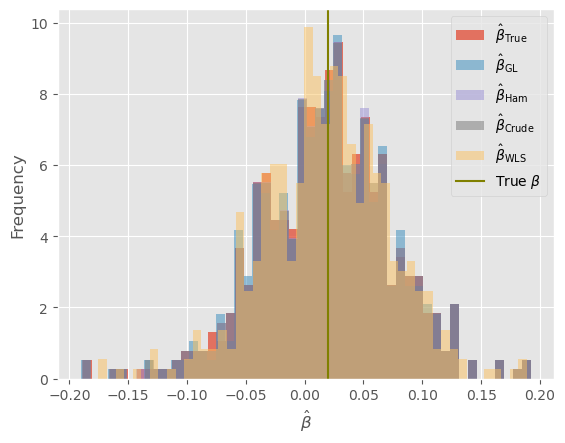

In [61]:
# plt.figure(figsize=(4,3))
# plt.hist(results[:,0],50,alpha = 0.5,density=True,label=r"$\hat\beta_{\mathrm{GLS}}$")
# plt.hist(results[:,1],50,alpha = 0.5,density=True,label=r"$\hat\beta_{\mathrm{WLS}}$")
plt.hist(oracle_pe_list,50,alpha=0.75,density=True,label=r"$\hat\beta_{\mathrm{True}}$")
plt.hist(GL_pe_list,50,alpha=0.5,density=True,label=r"$\hat\beta_{\mathrm{GL}}$")
plt.hist(hamling_pe_list,50,alpha=0.5,density=True,label=r"$\hat\beta_{\mathrm{Ham}}$")
plt.hist(crude_pe_list,50,alpha=0.5,density=True,label=r"$\hat\beta_{\mathrm{Crude}}$")
plt.hist(OLS_pe_list,50,alpha=0.5,density=True,label=r"$\hat\beta_{\mathrm{WLS}}$")
plt.axvline(x = 0.02, color = 'olive', label = r'True $\beta$')
plt.xlabel(r"$\hat \beta$")
plt.ylabel("Frequency")
plt.legend()
# plt.savefig("images/distribution_plot.pdf",bbox_inches="tight",pad_inches=0.1)
plt.show()